# Explore Polymarket history
Install `requirements-sandbox.txt` from the repository root, then select the repository's `.venv` kernel. This notebook loads saved data and runs offline. The final cell shows optional fresh-data calls.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from polytrader.data import load_history, fetch_price_history

# Works when the kernel starts in the repo root or sandbox/.
cwd = Path.cwd().resolve()
root = next((p for p in (cwd, *cwd.parents) if (p / 'src' / 'polytrader').is_dir()), None)

if root is None:
    raise RuntimeError('Start this notebook from the polytrader repository.')
root

WindowsPath('C:/Workspace/polytrader')

In [2]:
history_path = root / 'data' / 'lepen-history-7d.json'
if not history_path.exists():
    available = sorted((root / 'data').glob('*.json'))
    if not available:
        raise FileNotFoundError('Save a history JSON under data/ first; see the README.')
    history_path = available[0]

print(f'Loading: {history_path.name}')
history = load_history(history_path)
print(f'{len(history.data)} observations')
history.metadata

Loading: smoke-history-30d.json
238 observations


{'source': 'https://data-api.polymarket.com/v2/prices-history',
 'fetched_at': '2026-09-21T22:43:05.744754+00:00',
 'token_id': '4661468695364133352504208359262294490681982643646457249320367691664724099857',
 'window': {'start': '2026-08-22T22:43:05+00:00',
  'end': '2026-09-21T22:43:05+00:00',
  'start_inclusive': True,
  'end_exclusive': True},
 'requested_bucket_seconds': 10800}

In [3]:
df = history.to_frame()
df.head()

,timestamp,price,resolution_seconds
datetime,,,
2026-08-23 00:00:00+00:00,1787443200,0.24,10800
2026-08-23 03:00:00+00:00,1787454000,0.24,10800
2026-08-23 06:00:00+00:00,1787464800,0.24,10800
2026-08-23 09:00:00+00:00,1787475600,0.24,10800
2026-08-23 12:00:00+00:00,1787486400,0.24,10800


The index uses UTC; the original Unix-second `timestamp` remains a column. Check actual coverage and resolutions before comparing observations. The conversion does not fill gaps or resample. A resolution of zero can represent a settlement point.

In [4]:
print('First observation:', df.index.min())
print('Last observation: ', df.index.max())
df['resolution_seconds'].value_counts().sort_index()

First observation: 2026-08-23 00:00:00+00:00
Last observation:  2026-09-21 22:43:03+00:00


resolution_seconds
0          1
10800    237
Name: count, dtype: int64

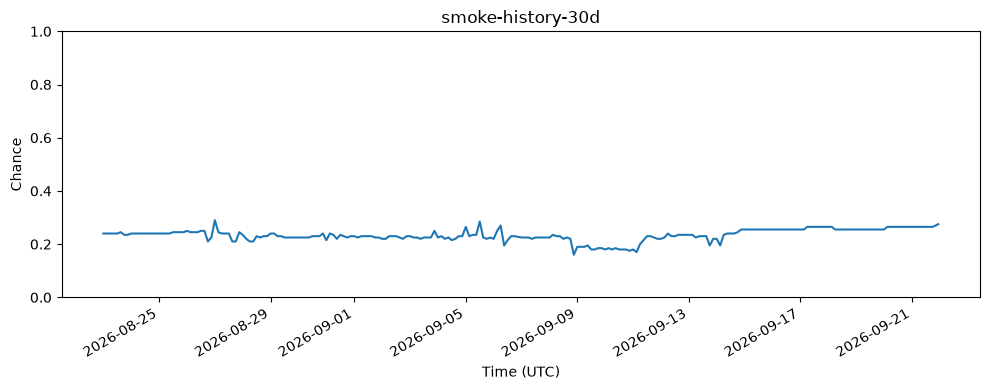

In [7]:
if df.empty:
    print('No observations to plot.')
else:
    title = history.metadata.get('market', {}).get('question', history_path.stem)
    ax = df['price'].plot(figsize=(10, 4), title=title)
    ax.set(xlabel='Time (UTC)', ylabel='Chance', ylim=(0, 1))
    plt.tight_layout()
    plt.show()

## Optional: fetch fresh data in Python
Uncomment one call below when you want to contact Polymarket. Use `days` OR `start`/`end`; dates use UTC and the end is exclusive. Saving is optional and existing files are protected from overwrite. These functions also work in regular Python scripts and future `polytrader.bot` modules.

In [ ]:
recent = fetch_price_history(
    token_id=history.metadata['token_id'], days=7, bucket_seconds=300,
)
recent.to_frame().head()

dated = fetch_price_history(
    token_id=history.metadata['token_id'],
    start='2026-09-01', end='2026-09-08',
)
dated.save(root / 'data' / 'new-history.json')